# Agent System Tests

Full end-to-end tests of the LangGraph agent graph.

Each test session is a **thread** (identified by `thread_id`). Calls on different threads
are independent; `AgentState` carries all state within a single run.

**Section order**
| # | Section | What you learn |
|---|---------|---------------|
| 1 | Classifier | How the router decides which agent path to follow |
| 2 | MCP create_building (direct) | Low-level JSON-RPC call to Grasshopper — no AI |
| 3 | ReAct agent | Agent thinks → acts → observes in a loop (adaptive, open-ended decisions) |
| 4 | Plan + Replan agent | Agent searches the web, then writes a step list from evidence (not fixed rules) |
| 5 | Full examples | One run per classification type, no forced routing |
| 6 | Conversation memory | How `MemorySaver` + `messages` reducer keeps one thread's history alive |

**Prerequisites:**
- Rhino + Grasshopper running with the Swiftlet MCP server active (port 5001)
- `settings.py` + `.env.local` configured
- Run from the `src/` directory


In [ ]:
## Setup — build graph
import os, sys, json, uuid, requests, importlib

# Ensure src/ is on the path
AGENT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if AGENT_ROOT not in sys.path:
    sys.path.insert(0, AGENT_ROOT)

# ── Force reload of all agent modules so edits take effect without kernel restart
import models.state
import config.design_rules
import nodes.building_design_node, nodes.classification_node
import nodes.search_node, nodes.planning_node, nodes.information_node
import nodes.climate_optimization_node
import graphs.main_graph

importlib.reload(models.state)
importlib.reload(config.design_rules)
importlib.reload(nodes.building_design_node)
importlib.reload(nodes.classification_node)
importlib.reload(nodes.search_node)
importlib.reload(nodes.planning_node)
importlib.reload(nodes.information_node)
importlib.reload(nodes.climate_optimization_node)
importlib.reload(graphs.main_graph)

from settings import LLM_PROVIDER, GEMINI_MODEL, MCP_GH_ENDPOINT
from graphs.main_graph import build_main_graph
from models.state import AgentState

graph = build_main_graph()
print(f"Graph built ✓  (provider={LLM_PROVIDER}, model={GEMINI_MODEL})")

try:
    resp = requests.post(
        MCP_GH_ENDPOINT,
        json={"jsonrpc": "2.0", "id": 1, "method": "tools/list", "params": {}},
        headers={"Content-Type": "application/json"},
        timeout=3,
    )
    tools = resp.json().get("result", {}).get("tools", [])
    names = [t["name"] for t in tools]
    print(f"MCP Server : ✓  tools={names}")
except Exception as e:
    print(f"MCP Server : ✗  not reachable at {MCP_GH_ENDPOINT}  ({e})")

# ── Thread helpers ────────────────────────────────────────────────────────────
def new_thread(label: str = None) -> dict:
    tid = label or str(uuid.uuid4())[:8]
    print(f"thread_id : {tid}")
    return {"configurable": {"thread_id": tid}, "recursion_limit": 50}


# ── Per-node compact renderer ─────────────────────────────────────────────────
def _render_node(node_name: str, d: dict):
    print(f"  ▶ [{node_name}]", end="")
    ctx = d.get("context") or {}

    if node_name == "classify_input":
        print(f"  →  request_type = {d.get('request_type', '?')}")
    # ── Plan & Execute — outer planner (decides scope + commits plan) ─────────
    elif node_name == "building_planner":
        plan = ctx.get("build_plan") or []
        hist  = d.get("history") or []
        entry = next((h for h in reversed(hist) if h.get("node") == "building_planner"), {})
        scope = entry.get("scope", "?")
        print(f"  scope: {scope}  →  {len(plan)}-step plan")
        for s in plan:
            print(f"           [{s.get('step','?')}] {s.get('task','')}")
    elif node_name in ("thinking", "execute_action"):
        thought = str(ctx.get("thought") or "").replace("\n", " ")[:80]
        action  = ctx.get("action") or {}
        print(f"  thought: {thought}")
        if action:
            print(f"           action : {action}")
        else:
            print()
    elif node_name == "create_building_as_box":
        box = ctx.get("box") or {}
        print(f"  gfa={box.get('gfa')}  width={box.get('width')}  "
              f"n_floors={box.get('n_floors')}  depth={box.get('depth')}")
    elif node_name == "compliance_check":
        issues = ctx.get("issues") or []
        if issues:
            print(f"  {len(issues)} issue(s):")
            for issue in issues:
                print(f"    • {issue}")
        else:
            print(f"  ✓ compliant")
    elif node_name == "is_compliant":
        itr = ctx.get("react_iteration", "?")
        print(f"  compliant = {ctx.get('compliant')}  (iteration {itr})")
    elif node_name in ("answer_with_search", "answer_without_search", "show_guide", "handle_unknown"):
        ans = str(d.get("answer") or "").replace("\n", " ")[:100]
        print(f"  {ans}{'…' if len(ans)==100 else ''}")
    # ── Climate optimization nodes (Plan+Replan) ──────────────────────────────
    elif node_name == "climate_investigate":
        loc  = ctx.get("climate_location", "?")
        hits = len(ctx.get("climate_search_results") or [])
        print(f"  location={loc}  search_hits={hits}")
    elif node_name == "climate_replan":
        steps = ctx.get("climate_remaining_steps") or []
        print(f"  {len(steps)}-step replan  (evidence-based, not rule-based)")
        for s in steps:
            print(f"           [{s.get('step','?')}] {s.get('action','?')}  {s.get('params',{})}  "
                  f"— {s.get('note','')[:60]}")
    elif node_name == "execute_climate_step":
        results = ctx.get("climate_step_results") or []
        last    = results[-1] if results else {}
        print(f"  step {last.get('step','?')} [{last.get('action','?')}]  "
              f"→  {str(last.get('result',''))[:60]}")
    elif node_name == "climate_summary":
        ans = str(d.get("answer") or "").replace("\n", " ")[:100]
        print(f"  {ans}{'…' if len(ans)==100 else ''}")
    else:
        print()


# ── run() ─────────────────────────────────────────────────────────────────────
def run(thread: dict, user_input: str, **kwargs) -> tuple:
    req = {"user_input": user_input, **kwargs}
    initial_state = AgentState(request=req)
    print(f"\n{'─'*72}")
    print(f"  INPUT : {user_input[:80]}{'…' if len(user_input)>80 else ''}")
    if kwargs:
        print(f"  PARAMS: {kwargs}")
    print(f"{'─'*72}")

    result = {}
    for update in graph.stream(initial_state, config=thread, stream_mode="updates"):
        for node_name, node_data in update.items():
            _render_node(node_name, node_data)
            result.update(node_data)

    answer = result.get("answer") or result.get("observation") or ""
    print(f"\n  ANSWER: {str(answer).replace(chr(10), ' ')[:120]}")
    return answer, result


  [llm] provider = gemini  model = gemini-2.5-flash-lite
Graph built ✓  (provider=gemini, model=gemini-2.5-flash-lite)
MCP Server : ✓  tools=['create_building', 'add_emergency_exits', 'rotate_building_toward_sunny_direction']


---
## 1 · Classifier — How the Router Decides

The **classifier** is the first node in the graph. It reads the user's message and assigns a `request_type`, which determines which agent branch runs next.

| `request_type` | Agent branch | Use when |
|---|---|---|
| `climate_optimization` | ReAct compliance loop → climate research → replan → rotate | User wants a code-compliant building **for a specific location**, with climate-optimised orientation |
| `design_building` | ReAct loop | User wants a compliant building sized automatically (no specific location) |
| `use_tool` | Single tool call | User asks to run one specific Grasshopper tool |
| `show_guide` | Static answer | User asks what the design rules are |
| `general_question` | Q&A ± web search | User asks an architecture question |
| `unknown` | Polite refusal | Off-topic request |

Run the cell below to test the classifier on sample prompts directly — no full graph run needed.


In [ ]:
# ── 1b: classification tests — call classify_input_fn directly (no graph run) ─
import importlib, nodes.classification_node, io
from contextlib import redirect_stdout
importlib.reload(nodes.classification_node)
from nodes.classification_node import classify_input_fn

CLASSIFIER_TESTS = [
    ("climate_optimization", "Design a 4-floor office building in Ho Chi Minh City, Vietnam, "
                             "oriented toward the most sun-facing direction based on local climate."),
    ("design_building",      "Design a 5-floor office building with a total area of 2000 m² that meets building code."),
    ("use_tool",             "Draw a cylinder at the origin with radius 5 and height 20."),
    ("show_guide",           "What are the design rules and constraints I need to follow for this project?"),
    ("general_question",     "What is the difference between a load-bearing wall and a curtain wall?"),
    ("unknown",              "What is the best pizza topping for a Friday night?"),
]

results = {}
for expected, prompt in CLASSIFIER_TESTS:
    state = AgentState(request={"user_input": prompt})
    with redirect_stdout(io.StringIO()):
        out = classify_input_fn(state)
    got = out.request_type
    ok  = got == expected
    results[expected] = {"got": got, "ok": ok}
    mark = "PASS ✓" if ok else "FAIL ✗"
    print(f"  {mark}  expected={expected:<25}  got={got:<25}  └─ {prompt[:55]}{'…' if len(prompt)>55 else ''}")

print()
passed = sum(1 for r in results.values() if r["ok"])
print(f"  {passed}/{len(results)} passed")


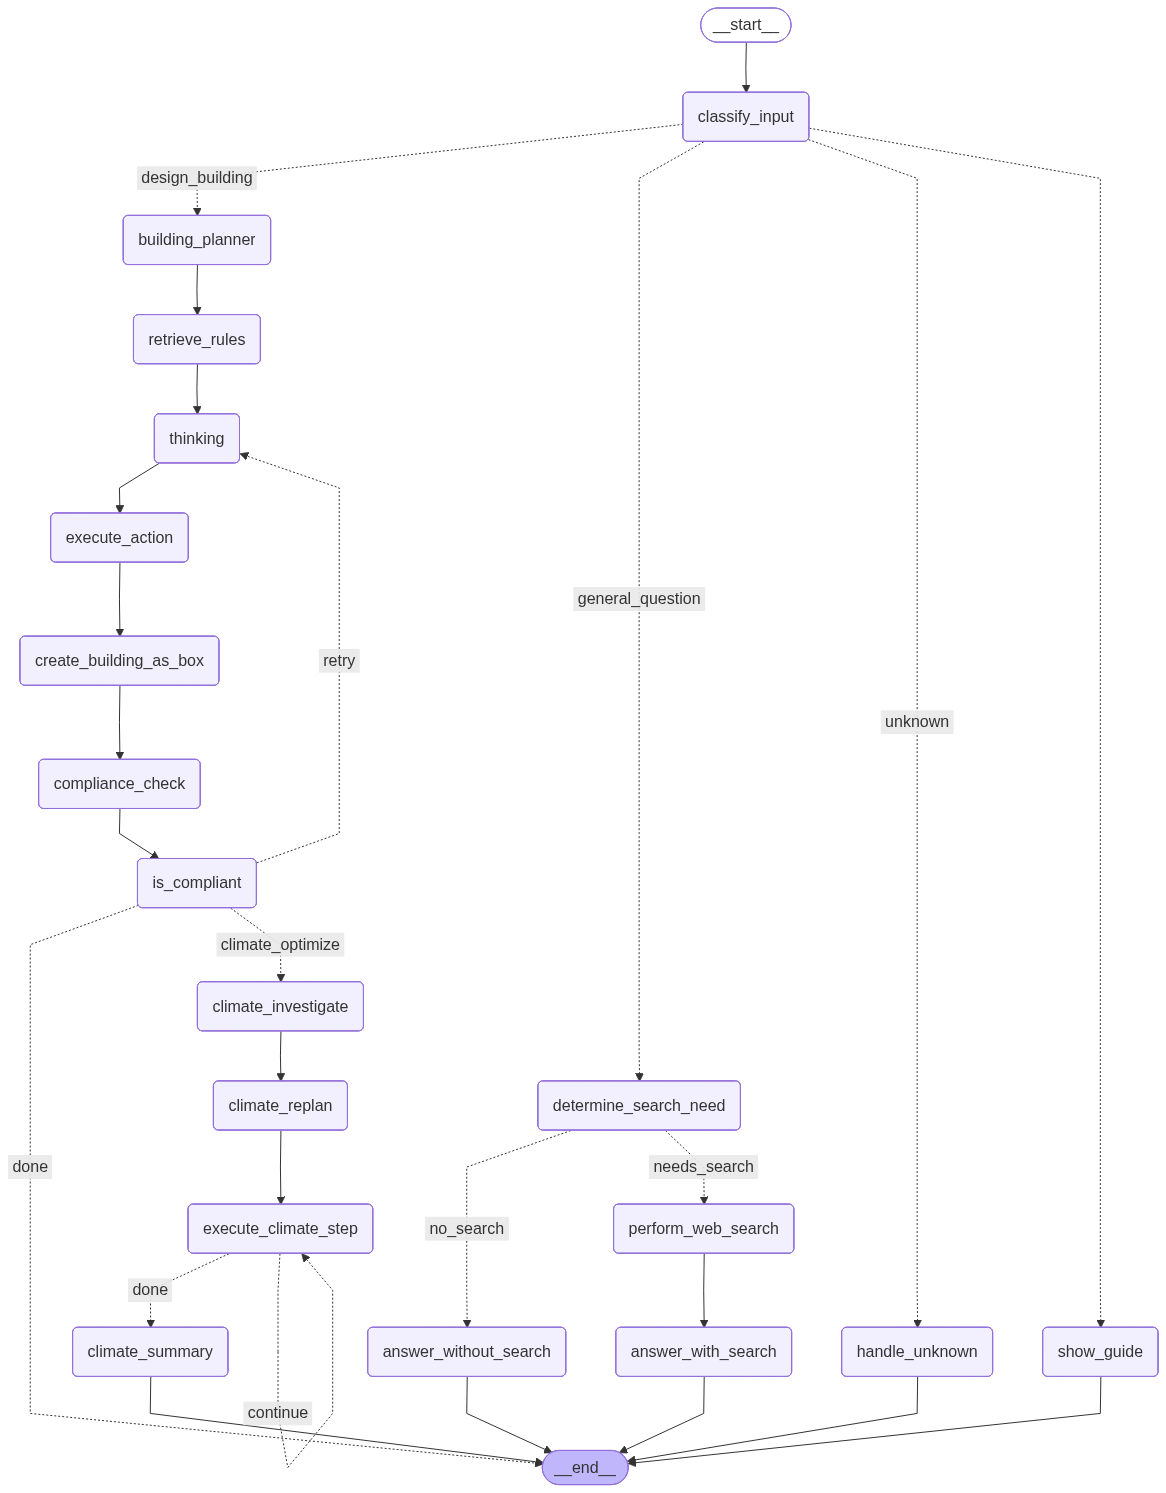

In [3]:

# ── Graph visualization — see how the router branches ─────────────────────────
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


---
## 2 · MCP Tool — Direct JSON-RPC Call (no AI)

Before adding any intelligence, let's understand the **raw tools** the agents will call.  
`create_building` and `add_emergency_exits` are Grasshopper components exposed over MCP.  
We call them directly via JSON-RPC 2.0 — no LangGraph, no LLM.

This confirms Rhino is running and shows exactly what each tool accepts and returns.


In [2]:
# ── 2a: list available MCP tools ─────────────────────────────────────────────
resp = requests.post(
    MCP_GH_ENDPOINT,
    json={"jsonrpc": "2.0", "id": 1, "method": "tools/list", "params": {}},
    headers={"Content-Type": "application/json"},
    timeout=5,
)
print(json.dumps(resp.json(), indent=2))


{
  "jsonrpc": "2.0",
  "id": 1,
  "result": {
    "tools": [
      {
        "name": "create_building",
        "description": "create a box-like building",
        "inputSchema": {
          "type": "object",
          "properties": {
            "site_area": {
              "type": "number",
              "description": "area of the building"
            },
            "width": {
              "type": "number",
              "description": "width of the building"
            },
            "number_of_floors": {
              "type": "integer",
              "description": "building 's number of floors"
            },
            "floor_height": {
              "type": "number",
              "description": "floor height"
            }
          },
          "required": [
            "site_area",
            "width",
            "number_of_floors",
            "floor_height"
          ]
        }
      },
      {
        "name": "add_emergency_exits",
        "description": "add_emer

In [6]:

# ── 2b: call create_building directly — inspect full JSON response + infer output schema
import ast

resp = requests.post(
    MCP_GH_ENDPOINT,
    json={
        "jsonrpc": "2.0",
        "id": 2,
        "method": "tools/call",
        "params": {
            "name": "create_building",
            "arguments": {
                "site_area": 150.0,     # footprint in m²
                "width": 10.0,
                "number_of_floors": 3,
                "floor_height": 4.0,
            },
        },
    },
    headers={"Content-Type": "application/json"},
    timeout=30,                     # GH may take a few seconds to compute geometry
)
data = resp.json()
print("── Full JSON-RPC response ───────────────────────────────────────")
print(json.dumps(data, indent=2))


── Full JSON-RPC response ───────────────────────────────────────
{
  "jsonrpc": "2.0",
  "id": 2,
  "result": {
    "content": [
      {
        "type": "text",
        "text": "{\r\n  \"width\": 10.0,\r\n  \"depth\": 15.0,\r\n  \"height\": 4.0,\r\n  \"ratio_constraint\": 0.6666666666666666,\r\n  \"gross_floor_area\": 450\r\n}"
      }
    ]
  }
}


In [5]:

# ── 2c: call add_emergency_exits directly — trigger the GH component ──────────
resp_exits = requests.post(
    MCP_GH_ENDPOINT,
    json={
        "jsonrpc": "2.0",
        "id": 3,
        "method": "tools/call",
        "params": {
            "name": "add_emergency_exits",
            "arguments": {
                "add": True,
            },
        },
    },
    headers={"Content-Type": "application/json"},
    timeout=30,                     # GH may take a few seconds to respond
)
data_exits = resp_exits.json()
print("── Full JSON-RPC response ───────────────────────────────────────")
print(json.dumps(data_exits, indent=2))


── Full JSON-RPC response ───────────────────────────────────────
{
  "jsonrpc": "2.0",
  "id": 3,
  "result": {
    "content": [
      {
        "type": "text",
        "text": "{\r\n  \"is_emergency_exits_added\": true\r\n}"
      }
    ]
  }
}


---
## 3 · Plan & Execute + ReAct — Building Design with Compliance Loop

> **How the planner works:**  
> `building_planner` runs first and makes **two decisions** before any execution starts:
> 1. **Scope** — *"Do I need compliance only, or compliance + climate optimization?"*  
>    It reads the user request and picks one of two scopes.
> 2. **Plan** — writes the matching step list (1 step or 3 steps) and commits it upfront.  
>
> This is the **Plan & Execute** pattern: the full intent is declared before any tool is called.

**Example output from `building_planner` (compliance-only request):**
```
▶  BUILDING PLANNER
┊  Scope  : compliance only
┊  Reason : No specific location or orientation goal was mentioned.
──────────────────────────────────────────────
┊  [1] Design a code-compliant building (dimensions, floors, emergency exits)
```

Then the **ReAct loop** executes step 1: picks a width, calls Grasshopper, checks compliance, loops until all rules pass.

**Graph path:** `building_planner → retrieve_rules → thinking → execute_action → create_building (MCP) → compliance_check → is_compliant` (loops back if not compliant)


In [8]:

# ── 3a: ReAct — maximize floors + react to initial 30m width ─────────────────
design_a = new_thread()   # random UUID — no stale checkpoint
answer_da, res_da = run(
    design_a,
    "Design a building with site area 150 m² that maximizes the number of floors ",
    # request_type="design_building",
    site_area=150,
    width=30,           # over the 20 m limit → agent must reduce
    n_floors=25,        # over the GFA limit and n_floors limit → agent must reduce
    floor_height=3.5,
)


thread_id : 6f8d090b

────────────────────────────────────────────────────────────────────────
  INPUT : Design a building with site area 150 m² that maximizes the number of floors 
  PARAMS: {'site_area': 150, 'width': 30, 'n_floors': 25, 'floor_height': 3.5}
────────────────────────────────────────────────────────────────────────
  ┊ pre-set: design_building
  ▶ [classify_input]  →  request_type = design_building
  ▶ [building_planner]  scope: compliance only  →  1-step plan
           [1] Design a code-compliant building (dimensions, floors, emergency exits) considering the site area of 150 m² and maximizing the number of floors. This will involve determining the maximum allowable building height based on typical zoning regulations (which are not provided, so assumptions will be made about a reasonable maximum height for a multi-story building on a small plot) and then calculating the number of floors that can fit within that height, ensuring adequate floor-to-floor heights and stru

---
## 4 · Climate Optimization — Plan & Execute (outer) + Plan + Replan (inner)

> **`climate_optimization`** route — A three-stage hierarchical agent:
> 1. **Stage 1 — Plan & Execute (outer scope decision)**: `building_planner` reads the user request, decides the scope is *"compliance + climate optimization"* (because a city was mentioned), and commits a 3-step plan upfront.
> 2. **Stage 2 — ReAct compliance loop**: iterates until the building passes all code checks (step 1 of the plan).
> 3. **Stage 3 — Plan + Replan**: web-searches the location's climate, then lets the LLM write the remaining orientation steps from what it finds — not from a fixed rule table (steps 2–3 of the plan).

### The planner's scope decision

`building_planner` first asks: *"compliance only, or compliance + climate?"*  
It reads the user input to decide — not a hardcoded rule.

**Example output (climate request):**
```
▶  BUILDING PLANNER
┊  Scope  : compliance + climate optimization
┊  Reason : User specified Ho Chi Minh City and asked for climate-oriented design.
──────────────────────────────────────────────
┊  [1] Design a code-compliant building (dimensions, floors, emergency exits)
┊  [2] Investigate local climate via web search
┊  [3] Optimise building orientation from climate evidence
```

This separates the *planning* concern from the *execution* concern — and makes the agent's full intent visible before any tool is called.

### Why "Plan + Replan" for the climate steps?

After the web search, the LLM reads the raw snippets and freely decides:

- **Which direction** to rotate (any degree 0–360, not just 0° or 180°)
- **How many steps** to write (1 to 3+, depending on what the research reveals)
- **What notes to add** (shading, ventilation, insulation — whatever the evidence suggests)

| Fixed pipeline | Plan + Replan (this agent) |
|---|---|
| `tropical → always 0°` | LLM reads raw snippets → picks any degree |
| Step count fixed at compile time | Step count decided at runtime |
| Same output for every tropical city | Output varies with what the web returns |

### Agent pattern comparison

| Pattern | Who writes the plan? | When? | Can steps change mid-run? |
|---|---|---|---|
| **Plan & Execute** (§3, §4 outer) | LLM decides scope + writes plan | Before any execution | No — plan committed once |
| **ReAct** (§3 inner loop) | LLM picks 1 next action | Each iteration | Yes — by choosing different tools |
| **Plan + Replan** (§4 inner climate stage) | LLM writes plan from web evidence | After `climate_investigate` | ✓ Yes — step list is generated at runtime |

### Full graph path
```
classify_input
  → building_planner                 (decides scope → commits plan upfront)
  → retrieve_rules → thinking → execute_action → create_building_as_box
  → compliance_check → is_compliant  (ReAct loop until compliant  — step 1 of plan)
  → climate_investigate              (web search for "{location} climate architecture"  — step 2)
  → climate_replan                   (LLM reads snippets → writes step list)
  → execute_climate_step  ──loop──▶  (rotate / add note per step  — step 3)
  → climate_summary
```


In [ ]:
# ── 4a: climate_optimization — Ho Chi Minh City ──────────────────────────────
#
# Plan & Execute (outer) + Plan+Replan (inner climate stage) flow:
#   building_planner    → commits 3-step plan upfront before any execution
#   [ReAct loop]        → designs compliant building (step 1 of plan)
#   climate_investigate → searches web: "climate Ho Chi Minh City architecture passive"  (step 2)
#   climate_replan      → LLM reads raw snippets → writes step list (degree chosen from evidence)
#   execute_climate_step → runs each step in the LLM-generated plan  (step 3)
#
# The LLM will likely rotate the building away from direct sun (high solar gain zone),
# but the exact degree and any extra notes depend on what the search returns.

solar_thread_hcm = new_thread("solar-hcm")
answer_solar_hcm, res_solar_hcm = run(
    solar_thread_hcm,
    "Design a compliant building with site area 200 m², 3 floors, floor height 3.5 m "
    "for Ho Chi Minh City, Vietnam. Orient it appropriately for the local climate.",
    site_area=200,
    n_floors=3,
    floor_height=3.5,
)


thread_id : solar-hcm

────────────────────────────────────────────────────────────────────────
  INPUT : Design a compliant building with site area 200 m², 3 floors, floor height 3.5 m …
  PARAMS: {'site_area': 200, 'n_floors': 3, 'floor_height': 3.5}
────────────────────────────────────────────────────────────────────────
  ┊ pre-set: climate_optimization
  ▶ [classify_input]  →  request_type = climate_optimization
  ▶ [building_planner]  scope: compliance + climate optimization  →  3-step plan
           [1] Design a code-compliant building with a site area of 200 m², 3 floors, and a floor height of 3.5 m, including considerations for emergency exits.
           [2] Investigate the climate of Ho Chi Minh City, Vietnam, focusing on solar radiation, prevailing winds, and temperature patterns.
           [3] Optimise the building's orientation on the 200 m² site to maximise natural ventilation and minimise solar heat gain, considering the findings from the climate investigation.
  ▶ [r

Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2 seconds as it raised DeadlineExceeded: 504 The request timed out. Please try again..


  ▶ [thinking]  thought: The user wants to design a compliant building. The site area is 200 m² and the n

  ▶ [execute_action]  thought: The user wants to design a compliant building. The site area is 200 m² and the n
           action : {'action': 'done', 'params': {}}
  ▶ [create_building_as_box]  gfa=None  width=None  n_floors=None  depth=None
  ▶ [compliance_check]  3 issue(s): Failed floor_height_constraint: Minimum floor height is 2.7m
  ▶ [is_compliant]  compliant = False  (iteration 1)
  [thinking] LLM error (AttributeError): 'list' object has no attribute 'strip'
  ▶ [thinking]  thought: LLM unavailable — using rule-based fallback.
           action : {'action': 'done', 'params': {}}
  ▶ [execute_action]  thought: LLM unavailable — using rule-based fallback.
           action : {'action': 'adjust_width', 'params': {'width': 10}}
  [create_building] → MCP site_area=200, width=10, n_floors=3, floor_height=3.5
  [create_building] ← [{'type': 'text', 'text': '{\r\n  "width": 10.0

In [ ]:
# ── 4c: climate_optimization — Berlin, Germany ───────────────────────────────
#
# Same graph, different location → different web evidence → different plan.
#
# Plan+Replan flow:
#   climate_investigate → searches web: "climate Berlin Germany architecture solar design passive"
#   climate_replan      → LLM reads those snippets → writes a different step list
#   execute_climate_step → runs the Berlin-specific plan
#
# KEY TEACHING POINT — compare the climate_replan output here vs §4a (HCM City):
#   • The LLM may choose a different rotation degree (e.g. 180° to face south)
#   • It may write additional steps (e.g. insulation note for cold months)
#   • Step count and content come from the web evidence, not from a rule table

solar_thread_ber = new_thread("solar-berlin")
answer_solar_ber, res_solar_ber = run(
    solar_thread_ber,
    "Design a compliant building with site area 200 m², 3 floors, floor height 3.5 m "
    "for Berlin, Germany. Orient it appropriately for the local climate.",
    site_area=200,
    n_floors=3,
    floor_height=3.5,
)

# ── Compare the runtime plans side-by-side ───────────────────────────────────
print("\n" + "="*60)
print("  PLAN+REPLAN COMPARISON  (steps written from web evidence)")
print("="*60)
for label, res in [("Ho Chi Minh City", res_solar_hcm), ("Berlin", res_solar_ber)]:
    ctx   = res.get("context") or {}
    steps = ctx.get("climate_remaining_steps") or []
    print(f"\n  {label}")
    for s in steps:
        print(f"    [{s.get('step')}] {s.get('action')}  params={s.get('params')}  -- {s.get('note','')}")
print()


thread_id : solar-berlin

────────────────────────────────────────────────────────────────────────
  INPUT : Design a compliant building with site area 200 m², 3 floors, floor height 3.5 m …
  PARAMS: {'site_area': 200, 'n_floors': 3, 'floor_height': 3.5}
────────────────────────────────────────────────────────────────────────
  ┊ pre-set: climate_optimization
  ▶ [classify_input]  →  request_type = climate_optimization
  ▶ [building_planner]  scope: compliance + climate optimization  →  3-step plan
           [1] Design a code-compliant building with a site area of 200 m², 3 floors, and a floor height of 3.5 m, including considerations for emergency exits.
           [2] Investigate the local climate of Berlin, Germany, focusing on solar radiation patterns, prevailing winds, and temperature variations throughout the year.
           [3] Optimise the building's orientation based on the climate evidence from Berlin to maximise passive solar heating in winter and minimise solar heat gain

---
## 5 · Full Agent Examples — one per classification

No `request_type` is forced in any cell below.  
The classifier runs first and routes to the correct branch automatically.

| Cell | Expected route         | Scenario                                                         |
|------|------------------------|------------------------------------------------------------------|
| 5a   | `design_building`      | Whole-building sizing with code compliance (no location)         |
| 5b   | `show_guide`           | Ask for design rules                                             |
| 5c   | `general_question`     | Architecture knowledge Q&A                                       |
| 5d   | `climate_optimization` | Building for a specific city → comply + climate-optimise orientation |
| 5e   | `unknown`              | Off-topic request                                                |
| 5f   | Summary                | Pass/fail table for all routes                                   |


In [ ]:

# ── 5a · design_building ──────────────────────────────────────────────────────
# Route: classify → retrieve_rules → thinking → execute_action
#        → create_building (MCP) → compliance_check → is_compliant (loop)
# site_area = footprint (m²);  GFA = site_area × n_floors must be ≤ 3000 m²
agent_design = new_thread("5a-design")
answer_design, res_design = run(
    agent_design,
    "Design a building with site area 300 m², 4 floors, and floor height 3.5 m "
    "that meets building code.",
    site_area=300,
    n_floors=4,
    floor_height=3.5,
)


In [ ]:
# ── 5b · show_guide ───────────────────────────────────────────────────────────
# Route: classify → show_guide → END
agent_guide = new_thread("5b-guide")
answer_guide, res_guide = run(
    agent_guide,
    "What are the design rules and constraints I need to follow for this project?",
)

In [ ]:
# ── 5c-1 · general_question — NO search needed ───────────────────────────────
# Route: classify → determine_search_need → answer_WITHOUT_search → END
# Fundamental architectural concept — the LLM answers from its training knowledge.
agent_qa = new_thread("5c-no-search")
answer_qa, res_qa = run(
    agent_qa,
    "What is the difference between a load-bearing wall and a curtain wall?",
)
print(f"  needs_search : {(res_qa.get('context') or {}).get('needs_search')}")


In [ ]:
# ── 5c-2 · general_question — search IS needed ─────────────────
# Route: classify → determine_search_need → answer_WITH_search → END
# Current-trends question — the LLM should recognise it needs a web search.
agent_qa2 = new_thread("5c-with-search")
answer_qa2, res_qa2 = run(
    agent_qa2,
    "What are the most prominent architecture and design trends emerging in 2025–2026, such as new materials, sustainable systems, or typological shifts?",
)
ctx_qa2 = res_qa2.get("context") or {}
print(f"  needs_search : {ctx_qa2.get('needs_search')}")
sr = ctx_qa2.get("search_results") or []
print(f"  search hits  : {len(sr)}")


In [ ]:
# ── 5c-2 · general_question — search IS needed ────────────────────────────────
# Route: classify → determine_search_need → answer_WITH_search → END
agent_qa2 = new_thread("5c-with-search")
answer_qa2, res_qa2 = run(
    agent_qa2,
    "What are the most prominent architecture and design trends emerging in 2025–2026, "
    "such as new materials, sustainable systems, or typological shifts?",
)

# ── Search diagnostics ────────────────────────────────────────────────────────
ctx_qa2  = res_qa2.get("context") or {}
needed   = ctx_qa2.get("needs_search")
sr       = ctx_qa2.get("search_results") or []

if needed is None:
    status = "⚠  needs_search not set (node may not have run)"
elif needed:
    status = f"✓  search ran  ({len(sr)} result{'s' if len(sr) != 1 else ''})"
else:
    status = "–  search skipped (LLM decided not needed)"

print(f"\n  Search status : {status}")

if sr:
    print(f"  {'#':<3}  {'Title / URL':<55}  Snippet")
    print("  " + "─" * 90)
    for idx, hit in enumerate(sr, 1):
        title   = str(hit.get("title") or hit.get("url") or "—")[:53]
        snippet = str(hit.get("snippet") or hit.get("content") or "—").replace("\n", " ")[:60]
        print(f"  {idx:<3}  {title:<55}  {snippet}{'…' if len(snippet)==60 else ''}")
elif needed:
    print("  (no results returned — check search tool / API key)")


In [ ]:
# ── 5d · climate_optimization — classifier decides ────────────────────────────
# Route: classify → retrieve_rules → (ReAct loop) → climate_investigate
#        → climate_replan → execute_climate_step (loop) → climate_summary → END
# The classifier detects "building design" + "specific location" + orientation intent
# and assigns request_type="climate_optimization" automatically.
agent_solar = new_thread("5d-climate-opt")
answer_solar5d, res_solar5d = run(
    agent_solar,
    "Design a building for Singapore with site area 250 m², 3 floors, and floor height 3.5 m "
    "that meets building code, and orient it toward the sunniest direction for the local climate.",
    site_area=250,
    n_floors=3,
    floor_height=3.5,
)
ctx_s = res_solar5d.get("context") or {}
print(f"\n  Location       : {ctx_s.get('climate_location')}")
print(f"  Rotation angle : {ctx_s.get('climate_azimuth')}°")
print(f"  Rotate success : {ctx_s.get('rotate_success')}")
steps = ctx_s.get("climate_remaining_steps") or []
print(f"  Steps in plan  : {len(steps)}  (written at runtime from web evidence)")


In [ ]:
# ── 5e · unknown ──────────────────────────────────────────────────────────────
# Route: classify → handle_unknown → END
agent_unknown = new_thread("5e-unknown")
answer_unknown, res_unknown = run(
    agent_unknown,
    "What is the best pizza topping for a Friday night?",
)

In [ ]:
# ── 5f · summary ──────────────────────────────────────────────────────────────
sessions = [
    ("design_building",      res_design),
    ("show_guide",           res_guide),
    ("general_question",     res_qa),
    ("climate_optimization", res_solar5d),
    ("unknown",              res_unknown),
]
print(f"  {'Expected':<25}  {'Got':<25}  Answer preview")
print("  " + "─" * 75)
for label, r in sessions:
    got  = r.get("request_type", "?")
    ans  = str(r.get("answer") or "").replace("\n", " ")[:50]
    mark = "✓" if got == label else f"✗ got '{got}'"
    print(f"  {label:<25}  {mark:<25}  {ans}{'…' if len(ans) == 50 else ''}")


---
## 6 · Conversation Memory — One Thread Remembers

> **Concept — how LangGraph memory works:**
>
> | Ingredient | Role |
> |---|---|
> | `MemorySaver` checkpointer | Saves the full `AgentState` after every node, keyed by `thread_id` |
> | Same `thread_id` across calls | Checkpointer reloads the previous snapshot — state accumulates |
> | New `thread_id` | No snapshot exists — fresh `AgentState` every time |

**No changes to any node.** `MemorySaver` plugs into the existing graph via `build_main_graph(checkpointer=memory)`.

**What is stored:** the entire `AgentState` — `request_type`, `answer`, `context`, `history` audit trail, everything — not just messages.

**What is NOT "memory" here:**  
This is *within-session* memory (RAM). Restarting the kernel clears it.  
Cross-session persistence requires a database-backed checkpointer (e.g. `SqliteSaver`).

**Run order:**
1. `6a` — build the graph with `MemorySaver`
2. `6b` — 3 turns on the **same thread** → inspect accumulated `history`
3. `6c` — 1 turn on a **new thread** → compare: only 1 entry, no prior state


In [ ]:

# ── 6a: Setup — rebuild graph WITH a MemorySaver checkpointer ────────────────
#
# MemorySaver stores the full AgentState in RAM, keyed by thread_id.
# Same thread_id  → resumes from the previous snapshot (state accumulates).
# New  thread_id  → starts completely fresh.
#
# No changes to any node — MemorySaver works with the existing graph as-is.

from langgraph.checkpoint.memory import MemorySaver
memory    = MemorySaver()
graph_mem = build_main_graph(checkpointer=memory)
print("Graph with MemorySaver ✓")



In [ ]:

# ── 6b: Three turns on the SAME thread — state accumulates ───────────────────
#
# Each call resumes from the previous snapshot.
# The AgentState grows: history gains one entry per turn.
# At the end, get_state() shows everything the agent "remembers" about this thread.

mem_thread = new_thread("6-memory-demo")

run(mem_thread, "What is a green roof and what are its main benefits?")
run(mem_thread, "What is passive solar design?")
run(mem_thread, "What is the difference between a load-bearing wall and a curtain wall?")

# ── Inspect what MemorySaver stored for this thread ──────────────────────────
snapshot = graph_mem.get_state(mem_thread)
state_vals = snapshot.values
history = state_vals.get("history") or []

print(f"\n{'='*64}")
print(f"  Thread '{mem_thread['configurable']['thread_id']}' — saved state")
print(f"{'='*64}")
print(f"  Turns completed : {len([h for h in history if h.get('node') == 'answer_without_search'])}")
print(f"  History entries : {len(history)}")
for h in history:
    node = h.get("node", "?")
    ans  = str(h.get("answer") or "").replace("\n", " ")[:70]
    if ans:
        print(f"  [{node}]  {ans}{'…' if len(ans)==70 else ''}")



In [ ]:

# ── 6c: New thread — clean slate ─────────────────────────────────────────────
#
# Different thread_id → MemorySaver has no snapshot for it → fresh AgentState.

fresh_thread = new_thread("6-fresh-thread")
run(fresh_thread, "What is passive solar design?")

snapshot_fresh = graph_mem.get_state(fresh_thread)
history_fresh  = (snapshot_fresh.values or {}).get("history") or []

print(f"\n  Thread '{fresh_thread['configurable']['thread_id']}' — history entries: {len(history_fresh)}")
print(f"  Thread '{mem_thread['configurable']['thread_id']}'   — history entries: {len((graph_mem.get_state(mem_thread).values or {}).get('history') or [])}")
print("\n  ── Teaching point ──────────────────────────────────────────────")
print("  Same graph, same node code — MemorySaver is the only difference.")
print("  The 3-turn thread kept all prior state; the fresh thread started clean.")

